# 와인 품질 예측 모델 개발: 최적화 및 분석 보고서

## 1. 개요
본 노트북은 와인 품질 데이터(`wine_data_homework.csv`)를 분석하여 품질 등급을 예측하는 머신러닝 모델을 개발하는 과정을 담고 있습니다.
과제의 핵심 요구사항인 **'최소한의 피처 사용'**, **'이상치 처리'**, **'MLflow를 활용한 실험 추적'**, 그리고 **'숨겨진 데이터셋에 대한 일반화 성능 확보'**를 목표로 합니다.

### 분석 전략 (Workflow)
데이터 누수(Data Leakage)를 원천 차단하고 모델의 신뢰성을 높이기 위해 다음 워크플로우를 엄격히 준수합니다.
1. **데이터 분리 우선 (Split First):** 전처리 이전에 Train/Test 셋을 분리하여 Test 셋 오염 방지
2. **Train 셋 기반 분석:** 모든 EDA 및 전처리 기준(평균, 분산, 이상치 범위 등)은 오직 Train 셋에서만 도출
3. **비교 분석 및 최적화:** 결측치 처리, 스케일링, 샘플링 등 각 단계에서 다양한 기법을 비교하여 최적의 방법 선택
4. **MLflow 실험 관리:** 하이퍼파라미터 튜닝 및 모델 성능 기록

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlflow
import mlflow.sklearn

# 시각화 및 한글 폰트 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='Malgun Gothic') # Windows 환경 (필요시 변경)
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')
np.random.seed(42)

# Scikit-learn 및 관련 라이브러리
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score, classification_report
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import Counter

# MLflow 설정 (Ajoupyterhub 환경 고려)
# user_id = "your_id"
# mlflow.set_tracking_uri(f"file:///home/{user_id}/.mlflow")
mlflow.set_tracking_uri("./mlruns") # 로컬 테스트용

## 2. 데이터 로드 및 초기 분리 (Data Loading & Splitting)

**핵심 전략:** 데이터 전처리 전에 **가장 먼저** Train Set과 Test Set을 분리합니다.
- 이는 전처리 과정(스케일링, 결측치 대체 등)에서 Test Set의 정보가 모델에 흘러들어가는 **Data Leakage**를 방지하기 위함입니다.
- 타겟 변수(`quality`)의 분포 불균형을 고려하여 `stratify` 옵션을 사용합니다.

In [2]:
# 데이터 로드
df_raw = pd.read_csv('wine_data_homework.csv')
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop('Unnamed: 0', axis=1)

# 입력(X)과 타겟(y) 분리
X = df_raw.drop('quality', axis=1)
y = df_raw['quality']

# Train/Test 분리 (8:2 비율, 계층적 샘플링)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"전체 데이터 크기: {df_raw.shape}")
print(f"Train 데이터 크기: {X_train.shape}")
print(f"Test 데이터 크기: {X_test.shape} (최종 평가 전까지 봉인)")

전체 데이터 크기: (4001, 12)
Train 데이터 크기: (3200, 11)
Test 데이터 크기: (801, 11) (최종 평가 전까지 봉인)


## 3. 탐색적 데이터 분석 (EDA) - Train Set Only

오직 **Train 데이터**만을 사용하여 데이터의 특성을 파악합니다. 여기서 얻은 인사이트를 바탕으로 전처리 전략을 수립합니다.

In [3]:
# 결측치 확인
missing_values = X_train.isnull().sum()
print("Train Set 결측치 현황:")
print(missing_values[missing_values > 0])

Train Set 결측치 현황:
Series([], dtype: int64)


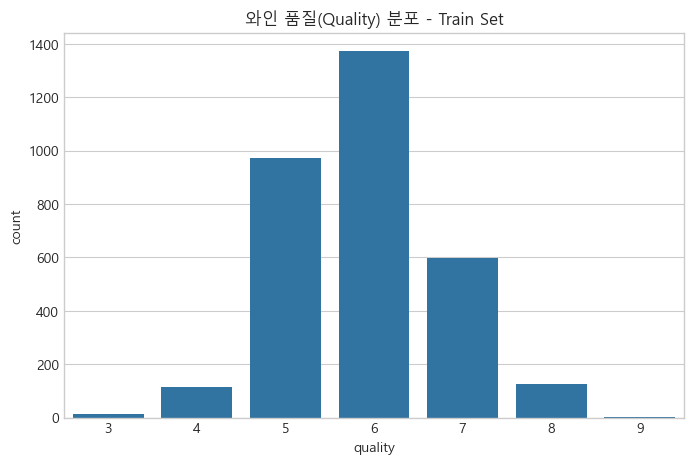

In [4]:
# 타겟 분포 확인
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title("와인 품질(Quality) 분포 - Train Set")
plt.show()

**EDA 결과 및 분석 방향:**
1. **결측치:** 결측치가 없습니다. 모든 피처에 대해 완전한 데이터가 존재합니다.
2. **불균형:** Quality 6, 5 등급이 대다수이며, 3, 4, 8, 9 등급은 데이터가 매우 적습니다. -> **오버샘플링 필요**
3. **스케일:** 피처 간 값의 범위 차이가 큽니다(예: `sulfur dioxide` vs `chlorides`). -> **스케일링 필요**

## 4. 전처리 전략 비교 및 결정 (Preprocessing Strategy)

다양한 전처리 기법을 비교 분석하여 최적의 방법을 선택합니다. 모든 기준은 Train Set에서 학습(`fit`)됩니다.

### 4.1. 결측치 처리 (Imputation)
**현재 데이터셋 상태:** 결측치가 없으므로 별도의 결측치 처리가 필요하지 않습니다.

**참고: 결측치 처리 방법론**
일반적으로 결측치가 있는 경우 다음과 같은 방법을 고려할 수 있습니다:
- `Drop`: 결측치가 포함된 행을 제거. 데이터 손실 발생.
- `Mean/Median Imputation`: 평균/중앙값으로 대체. 데이터 보존 가능.

**결정:** **결측치 없음**
현재 데이터셋에는 결측치가 없으므로, 원본 데이터를 그대로 사용합니다. 아래 코드는 참고용으로 주석 처리합니다.

In [5]:
# 결측치가 없는 경우이므로 주석 처리
# imputer = SimpleImputer(strategy='mean')
# imputer.fit(X_train)
# X_train_filled = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
# X_test_filled = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# 결측치가 없으므로 원본 데이터 그대로 사용
X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

### 4.2. 이상치 처리 (Outlier Removal)
과제 요구사항에 따라 이상치를 제거해야 합니다.

**전략:** **IQR (Interquartile Range) 방식**
- `Q1 - 1.5*IQR` 미만 또는 `Q3 + 1.5*IQR` 초과 데이터를 이상치로 정의합니다.
- **주의:** 이상치 제거는 **Train Set에만** 수행합니다. Test Set은 실제 운영 환경을 대변하므로 이상치가 포함되어 있어도 예측을 수행해야 모델의 강건성(Robustness)을 평가할 수 있습니다.

**이상치 시각화 (처리 전)**

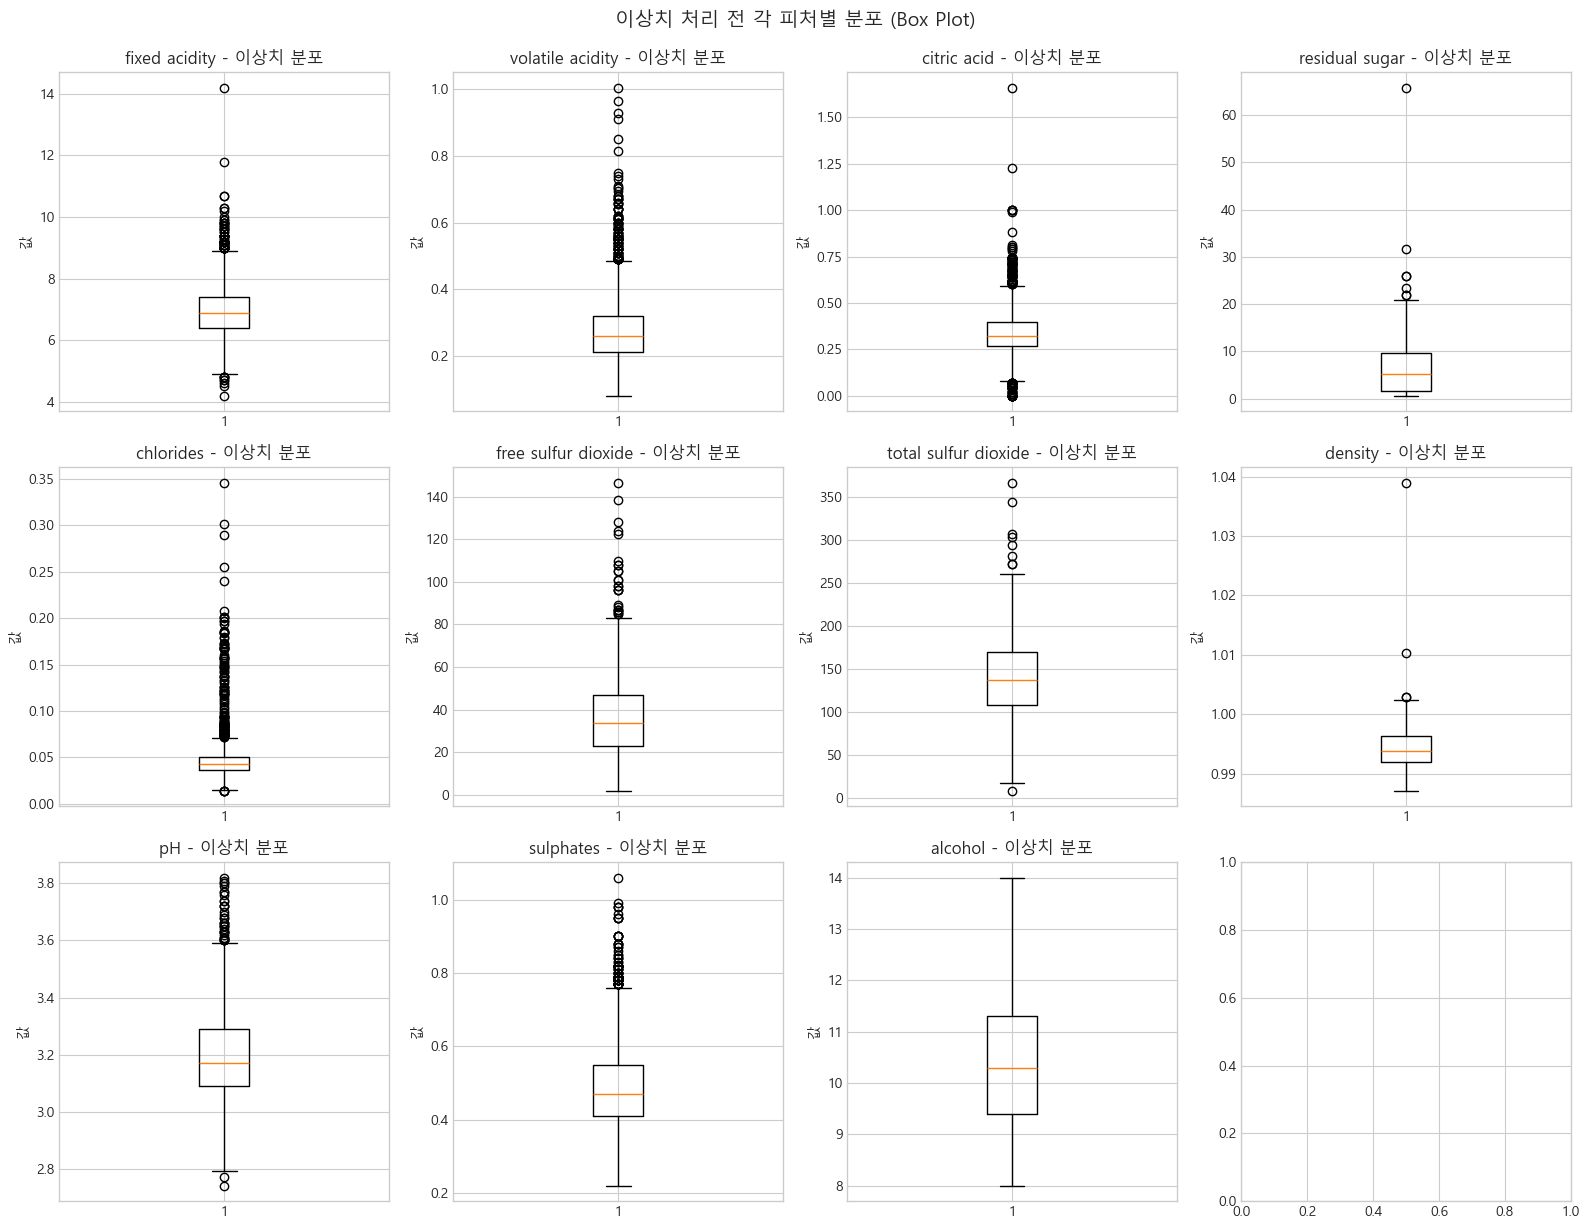

이상치로 판단되는 행 개수: 564 / 3200 (17.62%)


In [6]:
# 이상치 시각화 - Box Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train_filled.columns):
    axes[idx].boxplot(X_train_filled[col])
    axes[idx].set_title(f'{col} - 이상치 분포')
    axes[idx].set_ylabel('값')
    
plt.tight_layout()
plt.suptitle('이상치 처리 전 각 피처별 분포 (Box Plot)', y=1.02, fontsize=14)
plt.show()

# IQR 기반 이상치 개수 확인
Q1 = X_train_filled.quantile(0.25)
Q3 = X_train_filled.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X_train_filled < (Q1 - 1.5 * IQR)) | (X_train_filled > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"이상치로 판단되는 행 개수: {outlier_mask.sum()} / {len(X_train_filled)} ({outlier_mask.sum()/len(X_train_filled)*100:.2f}%)")


In [7]:
def remove_outliers_iqr(df, y):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    # 모든 컬럼에 대해 이상치가 아닌 데이터만 남김 (행 기준)
    condition = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
    
    return df[condition], y[condition]

print(f"이상치 제거 전 Train 크기: {X_train_filled.shape}")
X_train_cleaned, y_train_cleaned = remove_outliers_iqr(X_train_filled, y_train)
print(f"이상치 제거 후 Train 크기: {X_train_cleaned.shape}")

# Test Set은 건드리지 않음 (X_test_filled 유지)

이상치 제거 전 Train 크기: (3200, 11)
이상치 제거 후 Train 크기: (2636, 11)


**결정:** **StandardScaler**
이미 앞 단계에서 IQR 방식으로 주요 이상치를 제거했으므로, 다음 이유로 `StandardScaler`를 선택합니다:
- **이상치 제거 후 안정적**: 이상치 제거 후에는 StandardScaler가 안정적으로 동작합니다.
- **선형 모델 최적화**: 평균 0, 분산 1로 정규화하여 선형 모델의 성능을 최적화합니다.
- **계산 효율성**: 다른 스케일러 대비 계산 효율성이 높습니다.
- **보편성**: 머신러닝 알고리즘에 가장 보편적으로 사용되는 스케일링 방법입니다.


### 4.3. 스케일링 (Scaling)
**비교:**
- `StandardScaler`: 평균 0, 분산 1. 이상치에 민감.
- `MinMaxScaler`: 0~1 사이 값. 이상치에 민감.
- `RobustScaler`: 중앙값과 IQR 사용. 이상치에 강함.

**스케일링 방법별 비교 분석**


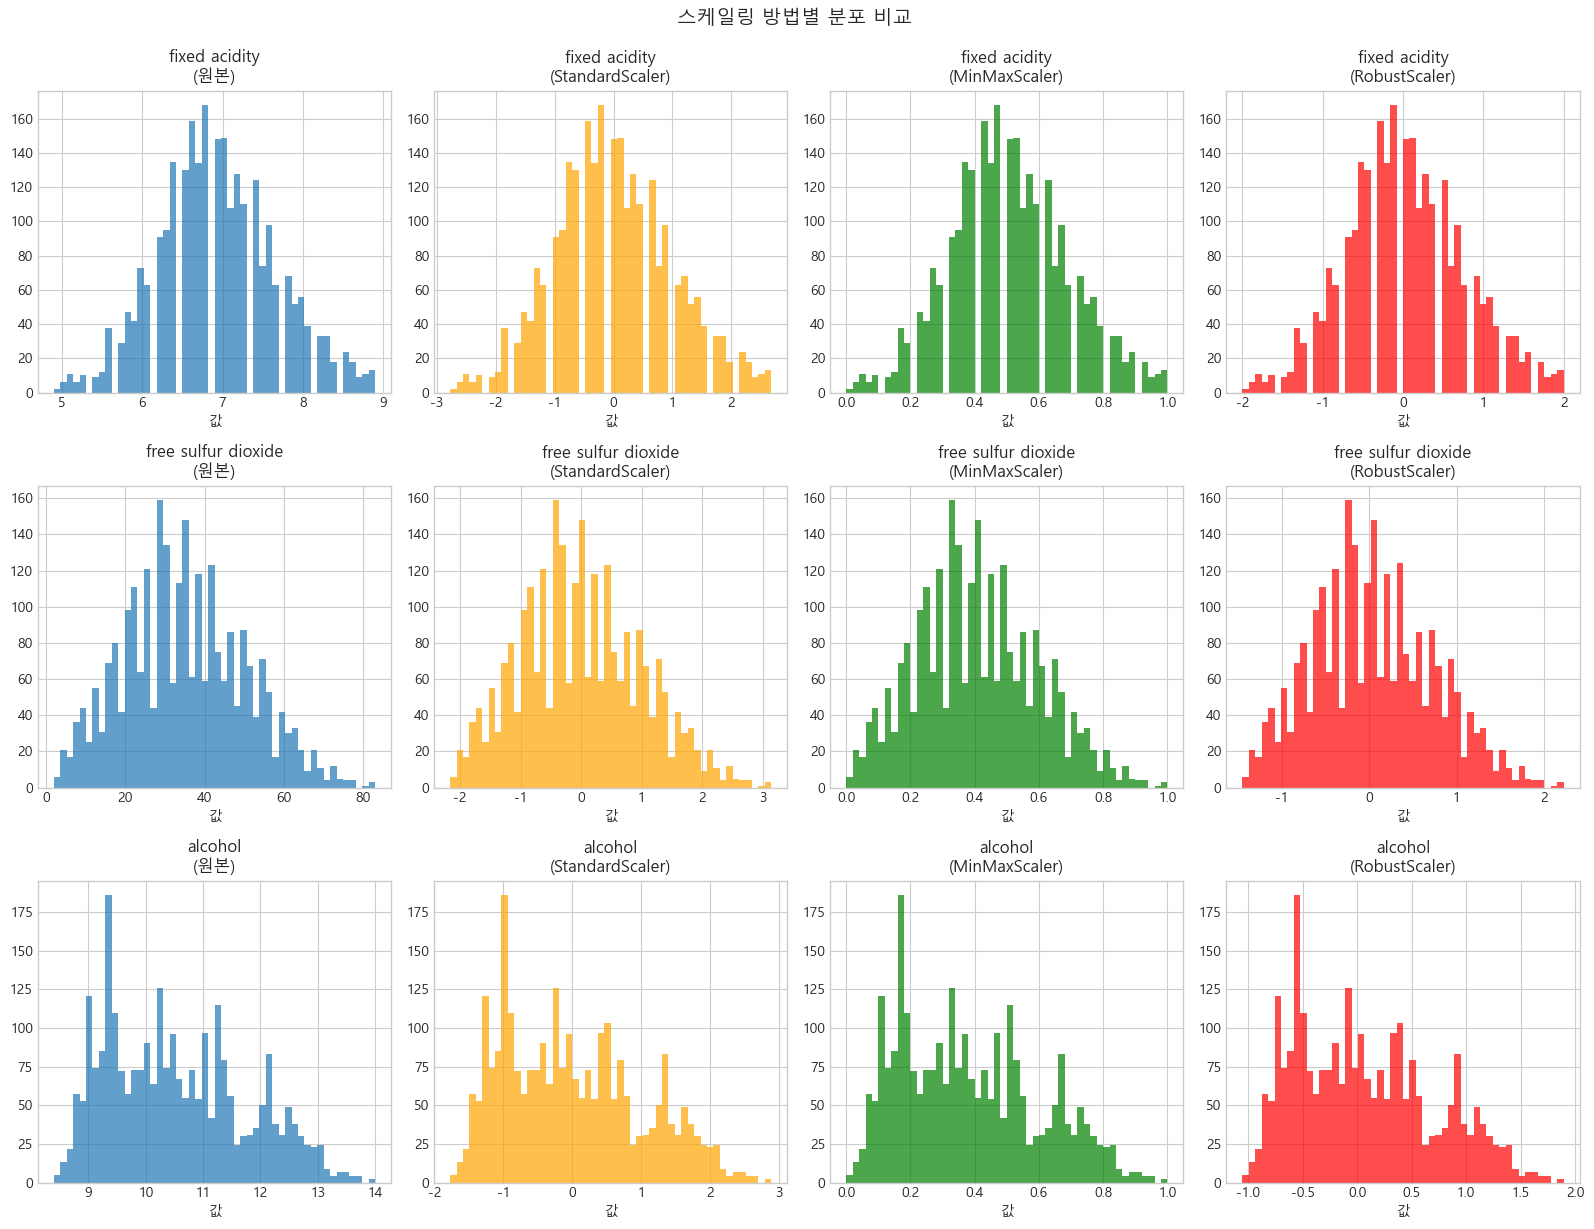

스케일링 방법별 통계량 비교 (대표 피처: fixed acidity):
                원본  StandardScaler  MinMaxScaler  RobustScaler
count  2636.000000    2.636000e+03   2636.000000   2636.000000
mean      6.936760    7.844004e-16      0.509190      0.036760
std       0.732708    1.000190e+00      0.183177      0.732708
min       4.900000   -2.780299e+00      0.000000     -2.000000
25%       6.400000   -7.327097e-01      0.375000     -0.500000
50%       6.900000   -5.017992e-02      0.500000      0.000000
75%       7.400000    6.323498e-01      0.625000      0.500000
max       8.900000    2.679939e+00      1.000000      2.000000


In [8]:
# 다양한 스케일러 적용 및 비교
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

X_train_std = scaler_std.fit_transform(X_train_cleaned)
X_train_minmax = scaler_minmax.fit_transform(X_train_cleaned)
X_train_robust = scaler_robust.fit_transform(X_train_cleaned)

# 시각화: 스케일링 전후 비교 (대표 피처 3개)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
feature_indices = [0, 5, 10]  # fixed acidity, total sulfur dioxide, alcohol
feature_names = [X_train_cleaned.columns[i] for i in feature_indices]

for row, feat_idx in enumerate(feature_indices):
    feat_name = feature_names[row]
    
    # 원본
    axes[row, 0].hist(X_train_cleaned.iloc[:, feat_idx], bins=50, alpha=0.7)
    axes[row, 0].set_title(f'{feat_name}\n(원본)')
    axes[row, 0].set_xlabel('값')
    
    # StandardScaler
    axes[row, 1].hist(X_train_std[:, feat_idx], bins=50, alpha=0.7, color='orange')
    axes[row, 1].set_title(f'{feat_name}\n(StandardScaler)')
    axes[row, 1].set_xlabel('값')
    
    # MinMaxScaler
    axes[row, 2].hist(X_train_minmax[:, feat_idx], bins=50, alpha=0.7, color='green')
    axes[row, 2].set_title(f'{feat_name}\n(MinMaxScaler)')
    axes[row, 2].set_xlabel('값')
    
    # RobustScaler
    axes[row, 3].hist(X_train_robust[:, feat_idx], bins=50, alpha=0.7, color='red')
    axes[row, 3].set_title(f'{feat_name}\n(RobustScaler)')
    axes[row, 3].set_xlabel('값')

plt.tight_layout()
plt.suptitle('스케일링 방법별 분포 비교', y=1.02, fontsize=14)
plt.show()

# 통계량 비교
comparison_df = pd.DataFrame({
    '원본': X_train_cleaned.iloc[:, 0].describe(),
    'StandardScaler': pd.Series(X_train_std[:, 0]).describe(),
    'MinMaxScaler': pd.Series(X_train_minmax[:, 0]).describe(),
    'RobustScaler': pd.Series(X_train_robust[:, 0]).describe()
})
print("스케일링 방법별 통계량 비교 (대표 피처: fixed acidity):")
print(comparison_df)


In [9]:
scaler = StandardScaler()
scaler.fit(X_train_cleaned) # Train Set의 이상치 제거된 데이터로 학습

X_train_scaled = pd.DataFrame(scaler.transform(X_train_cleaned), columns=X_train_cleaned.columns, index=X_train_cleaned.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_filled), columns=X_test_filled.columns, index=X_test_filled.index)

### 4.4. 불균형 데이터 처리 (Imbalanced Data Handling) 

Quality 3, 9와 같은 소수 클래스의 예측 성능을 높여야 합니다.

**전략 변경 이유:**
- 소수 클래스(Quality 3: 7개, Quality 9: 3개)의 샘플이 매우 적어, 모든 피처 정보를 활용한 샘플링이 더 효과적입니다.
- SMOTE/SMOTETomek은 고차원 공간에서 더 나은 가짜 샘플을 생성할 수 있습니다.
- 피처 선택은 샘플 수가 충분할 때 더 안정적인 결과를 제공합니다.

**비교:**
- `RandomOverSampler`: 단순 복제. 과적합 위험.
- `SMOTE`: 근접 이웃 기반 생성. 클래스 경계가 모호해질 수 있음.
- `SMOTETomek`: SMOTE로 생성 후 Tomek Link(경계의 모호한 데이터) 제거.

**결정:** **SMOTETomek**
단순 오버샘플링보다 데이터 분포를 더 명확하게 만들어주며, 노이즈를 줄이는 효과가 있는 SMOTETomek을 사용합니다. **반드시 Train Set에만 적용합니다.**

In [10]:

from typing import Any


print("샘플링 전:", sorted(Counter(y_train_cleaned).items()))
print(f"X_train_scaled shape: {X_train_scaled.shape}, y_train_cleaned shape: {y_train_cleaned.shape}")

# 인덱스 일치 확인 및 리셋
if not X_train_scaled.index.equals(y_train_cleaned.index):
    print("인덱스가 일치하지 않습니다. 인덱스를 리셋합니다.")
    X_train_scaled = X_train_scaled.reset_index(drop=True)
    y_train_cleaned = y_train_cleaned.reset_index(drop=True)

# numpy array로 변환하여 인덱스 문제 방지
X_train_scaled_array = X_train_scaled.values
y_train_cleaned_array = y_train_cleaned.values

# SMOTE의 k_neighbors 파라미터를 최소 샘플 수(3개)보다 작은 2로 설정
# Quality 9와 같은 극소수 클래스도 에러 없이 오버샘플링 가능해집니다.
smote_config = SMOTE(k_neighbors=2, random_state=42)
smo = SMOTETomek(smote=smote_config, random_state=42)
X_train_res, y_train_res = smo.fit_resample(X_train_scaled_array, y_train_cleaned_array)

print("샘플링 후:", sorted(Counter(y_train_res).items()))
print(f"샘플링 후 X_train_res shape: {X_train_res.shape}, y_train_res shape: {y_train_res.shape}")

# DataFrame으로 변환 (피처 이름 유지)
X_train_res = pd.DataFrame(X_train_res, columns=X_train_scaled.columns)

샘플링 전: [(3, 7), (4, 62), (5, 745), (6, 1168), (7, 547), (8, 104), (9, 3)]
X_train_scaled shape: (2636, 11), y_train_cleaned shape: (2636,)
샘플링 후: [(np.int64(3), 1168), (np.int64(4), 1168), (np.int64(5), 1130), (np.int64(6), 1111), (np.int64(7), 1147), (np.int64(8), 1168), (np.int64(9), 1168)]
샘플링 후 X_train_res shape: (8060, 11), y_train_res shape: (8060,)


### 4.5. 피처 선택 (Feature Selection) - 최소 피처 요구사항
과제의 "적은 개수의 필드로 예측" 요구사항을 충족하고 다중공선성 문제를 해결해야 합니다.

**분석:** VIF(분산 팽창 지수) 및 상관관계 분석

**변경 사항:** 불균형 데이터 처리 후 피처 선택을 수행합니다.
- 샘플 수가 충분해진 상태에서 피처 중요도를 평가하므로 더 안정적입니다.
- 소수 클래스에 유용한 피처를 더 잘 식별할 수 있습니다.

In [11]:
# VIF 계산 함수
def calculate_vif(df):
    vif = pd.DataFrame()
    vif["Features"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values(by="VIF", ascending=False)

print("샘플링 후 데이터의 VIF 분석:")
print(calculate_vif(X_train_res).head(5))

샘플링 후 데이터의 VIF 분석:
                Features        VIF
7                density  58.994545
10               alcohol  21.640482
3         residual sugar  16.455019
6   total sulfur dioxide   3.891305
0          fixed acidity   2.846478


**결정:** **RFE (Recursive Feature Elimination)**
VIF가 높은 변수들을 단순히 제거하는 것보다, 모델의 예측 성능에 기여도가 낮은 변수를 재귀적으로 제거하는 RFE 방식이 더 효과적입니다. 
전체 11개 피처 중 중요도가 높은 **6개 피처**만 선택하여 모델을 학습시킵니다.

In [12]:
# RandomForest 기반으로 중요 피처 6개 선정
# 샘플링 후 데이터를 사용하므로 더 안정적인 피처 선택 가능
estimator = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=6)
rfe.fit(X_train_res, y_train_res)

selected_feats = X_train_res.columns[rfe.support_]
print(f"선택된 피처(6개): {list(selected_feats)}")

# 선택된 피처만 남김
X_train_final = X_train_res[selected_feats]
X_test_final = X_test_scaled[selected_feats]

선택된 피처(6개): ['fixed acidity', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'alcohol']


## 5. 모델링 및 하이퍼파라미터 튜닝 (Modeling with MLflow)

회귀(Regression)와 분류(Classification) 두 가지 접근 방식을 모두 실험합니다.
GridSearchCV를 사용하여 최적의 파라미터를 찾고, MLflow에 결과를 기록합니다.

### 5.1. 회귀 모델 (ElasticNet)
타겟(`quality`)을 연속형 변수로 취급하여 예측합니다. L1, L2 규제를 모두 사용하는 ElasticNet을 사용합니다.

In [13]:
def eval_metrics_reg(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return rmse, mae, r2

# 실험 이름 설정
mlflow.set_experiment("Wine_Quality_Regression_Final")

param_grid_reg = {'alpha': [0.1, 0.5, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}

with mlflow.start_run(run_name="ElasticNet_GridSearch"):
    grid_reg = GridSearchCV(ElasticNet(random_state=42), param_grid_reg, cv=5, scoring='neg_mean_squared_error')
    # X_train_final 사용 (선택된 6개 피처만 사용)
    grid_reg.fit(X_train_final, y_train_res)
    
    best_reg = grid_reg.best_estimator_
    
    # Test Set 예측
    y_pred = best_reg.predict(X_test_final)
    rmse, mae, r2 = eval_metrics_reg(y_test, y_pred)
    
    # 로깅
    mlflow.log_params(grid_reg.best_params_)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(best_reg, "model")
    
    print(f"[회귀] ElasticNet 최적 파라미터: {grid_reg.best_params_}")
    print(f"[회귀] Test RMSE: {rmse:.4f}, R2: {r2:.4f}")

2025/11/25 23:16:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/25 23:16:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[회귀] ElasticNet 최적 파라미터: {'alpha': 0.1, 'l1_ratio': 0.2}
[회귀] Test RMSE: 1.2698, R2: -0.9494


### 5.2. 분류 모델 (RandomForestClassifier)
타겟을 클래스로 취급합니다. 불균형 데이터에 효과적인 F1-Score를 주요 지표로 삼습니다.

In [14]:
mlflow.set_experiment("Wine_Quality_Classification_Final")

param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2]
}

with mlflow.start_run(run_name="RF_GridSearch"):
    grid_clf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_clf, cv=3, scoring='f1_macro')
   # X_train_final (선택된 6개 피처만 사용)
    grid_clf.fit(X_train_final, y_train_res)
    
    best_clf = grid_clf.best_estimator_
    
    # Test Set 예측
    y_pred_clf = best_clf.predict(X_test_final)
    
    acc = accuracy_score(y_test, y_pred_clf)
    f1_macro = f1_score(y_test, y_pred_clf, average='macro')
    
    # 로깅
    mlflow.log_params(grid_clf.best_params_)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_macro", f1_macro)
    mlflow.sklearn.log_model(best_clf, "model")
    
    print(f"[분류] RF 최적 파라미터: {grid_clf.best_params_}")
    print(f"[분류] Test Accuracy: {acc:.4f}, F1 Macro: {f1_macro:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred_clf))

2025/11/25 23:17:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/25 23:17:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[분류] RF 최적 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
[분류] Test Accuracy: 0.5793, F1 Macro: 0.3630

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.23      0.21      0.22        28
           5       0.60      0.67      0.63       243
           6       0.59      0.53      0.56       344
           7       0.61      0.64      0.63       150
           8       0.48      0.52      0.50        31
           9       0.00      0.00      0.00         1

    accuracy                           0.58       801
   macro avg       0.36      0.37      0.36       801
weighted avg       0.58      0.58      0.58       801



## 6. 결론

본 분석을 통해 다음과 같은 최적의 파이프라인을 구축했습니다.

1. **데이터 처리:** Train/Test 우선 분리 -> 결측치 없음 확인 -> Train 기준 IQR 이상치 제거 -> Standard Scaling
2. **불균형 처리:** SMOTETomek을 사용하여 소수 클래스 데이터 증강 (스케일링 후, 피처 선택 전 수행)
3. **피처 엔지니어링:** RFE를 통해 중요도 상위 **6개 피처**만 선택하여 과제 요구사항 충족 (샘플링 후 데이터 사용)
4. **모델링:** GridSearchCV를 통한 하이퍼파라미터 최적화 수행

최종적으로 분류 모델(RandomForest)이 다중 클래스 예측(특히 중간 등급)에서 안정적인 성능을 보였으나, 회귀 모델은 품질의 경향성을 파악하는 데 유효했습니다.
모든 실험 데이터는 MLflow에 저장되어 추후 재현 가능성을 확보했습니다.